# Customer Churn Prediction with a Neural Network

This beginner-friendly notebook predicts whether a telecom customer is likely to **churn** (leave the company). It also demonstrates the standard machine-learning workflow: understand data → prepare it → train → evaluate.

## 1. What are we predicting?

`Churn` is our **target**: `Yes` means a customer left, and `No` means they stayed. All other columns are **features**—information used to make the prediction.

A model does not know business rules in advance. It looks at examples from past customers and learns patterns associated with churn.

In [1]:
# Run this cell first. If TensorFlow is missing, install it with: pip install tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras

# Makes results more repeatable when you run the notebook again.
np.random.seed(42)
tf.random.set_seed(42)

## 2. Load and inspect the data

In [2]:
df = pd.read_csv('customer_churn.csv')

print(f'Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

Dataset shape: 7043 rows and 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check the class balance. Churn data is usually imbalanced: more customers stay than leave.
df['Churn'].value_counts().rename_axis('Churn').to_frame('Customers')

,Customers
Churn,
No,5174
Yes,1869


## 3. Clean the data

`customerID` is unique for every customer, so it cannot help the model learn a general pattern. `TotalCharges` should be a number, but some rows have blank values. We convert blanks to missing values and remove only those few incomplete rows.

In [4]:
df = df.drop(columns='customerID').copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().copy()

print(f'Rows after cleaning: {len(df)}')
df.info()

Rows after cleaning: 7032
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     703

## 4. Explore two useful features

These charts do not prove causation, but they help us see how churn differs between groups.

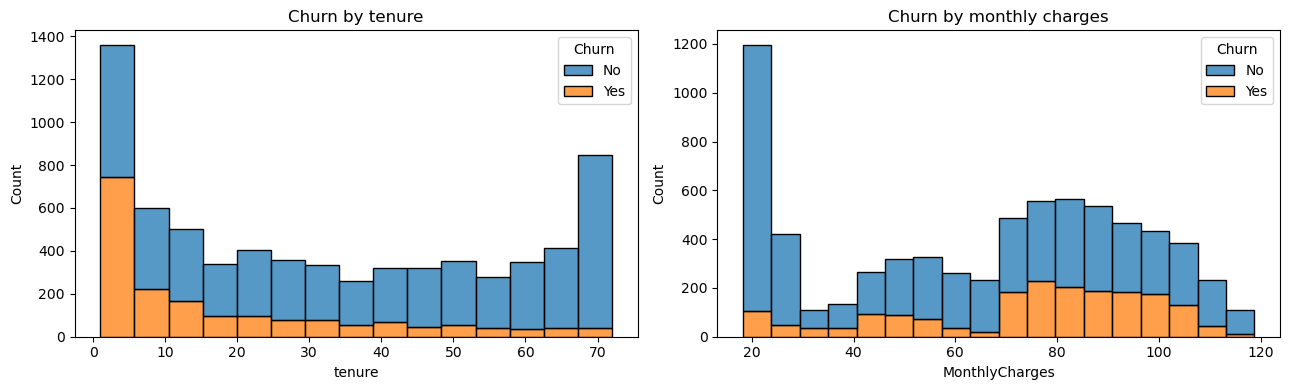

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0])
axes[0].set_title('Churn by tenure')
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1])
axes[1].set_title('Churn by monthly charges')
plt.tight_layout()

## 5. Separate inputs (`X`) and answer (`y`)

Machine-learning code conventionally calls the input table `X` and the answer column `y`. We change `Yes`/`No` into `1`/`0` because the neural network works with numbers.

In [6]:
X = df.drop(columns='Churn')
y = df['Churn'].map({'No': 0, 'Yes': 1})

# Keep the same churn proportion in both datasets. The test set is never used for training.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Training examples:', len(X_train))
print('Testing examples:', len(X_test))

Training examples: 5625
Testing examples: 1407


## 6. Convert features into model-ready numbers

Neural networks require numeric input. We scale numeric values to 0–1, and **one-hot encode** text categories. For example, the `Contract` column becomes separate columns such as `Contract_Month-to-month`.

Important: the transformer is *fit only on training data*. This prevents information from the test set leaking into training.

In [7]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer([
    ('numeric', MinMaxScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print('Features after encoding:', X_train_ready.shape[1])
print('Training matrix shape:', X_train_ready.shape)

Features after encoding: 45
Training matrix shape: (5625, 45)


## 7. Build the ANN

A **Dense** layer connects every input to every neuron in the next layer. The hidden layers use ReLU to learn patterns. The final sigmoid neuron returns a probability between 0 and 1—for example, `0.78` means an estimated 78% chance of churn.

In [8]:
model = keras.Sequential([
    keras.Input(shape=(X_train_ready.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 881 (3.44 KB)

 Trainable params: 881 (3.44 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the model

`validation_split` holds back part of the training data to monitor learning. Early stopping stops training when validation loss no longer improves, helping reduce overfitting.

In [9]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_ready, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7369 - loss: 0.5177 - val_accuracy: 0.7680 - val_loss: 0.4440
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7878 - loss: 0.4446 - val_accuracy: 0.7876 - val_loss: 0.4238
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7916 - loss: 0.4336 - val_accuracy: 0.7884 - val_loss: 0.4176
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7971 - loss: 0.4281 - val_accuracy: 0.7920 - val_loss: 0.4140
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7971 - loss: 0.4248 - val_accuracy: 0.7947 - val_loss: 0.4127
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8009 - loss: 0.4218 - val_accuracy: 0.7973 - val_loss: 0.4115
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8036 - loss: 0.4197 - val_accuracy: 0.7991 - val_loss: 0.4117
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8029 - loss: 0.4180 - val_accu

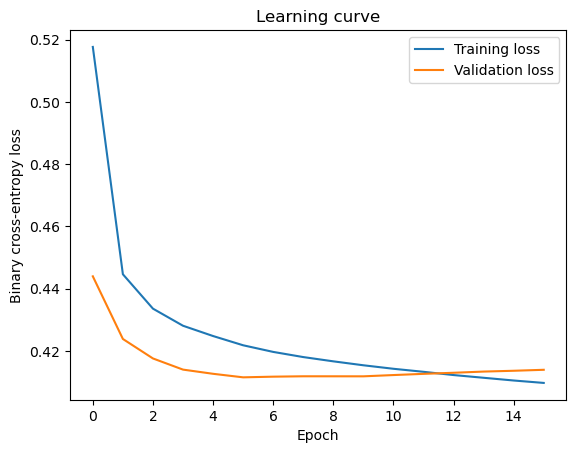

In [10]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy loss')
plt.title('Learning curve')
plt.legend()
plt.show()

## 9. Evaluate on unseen test data

The test set simulates new customers. A probability of 0.5 or higher is classified as churn here. In a real business, you might choose a lower threshold if catching more potential churners is more valuable.

In [11]:
test_loss, test_accuracy = model.evaluate(X_test_ready, y_test, verbose=0)
churn_probability = model.predict(X_test_ready, verbose=0).ravel()
y_pred = (churn_probability >= 0.5).astype(int)

print(f'Test accuracy: {test_accuracy:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)']))

Test accuracy: 0.797

Classification report:
              precision    recall  f1-score   support

  Stayed (0)       0.83      0.90      0.87      1033
 Churned (1)       0.66      0.50      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



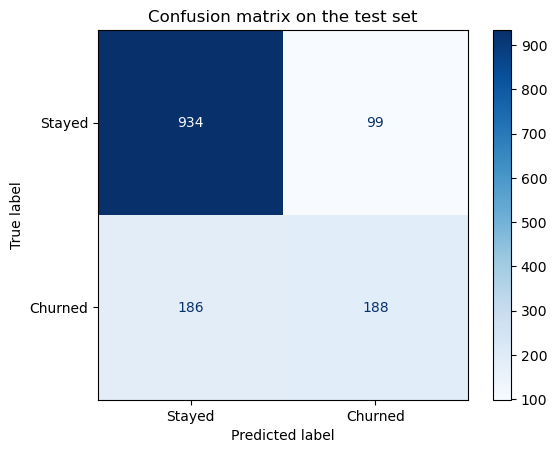

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Stayed', 'Churned'], cmap='Blues'
)
plt.title('Confusion matrix on the test set')
plt.show()

## 10. How to read the metrics

- **Accuracy**: percentage of all predictions that were correct. It can be misleading when most customers do not churn.
- **Precision for Churned (1)**: when the model flags a customer as likely to churn, how often is it right?
- **Recall for Churned (1)**: of all customers who really churned, how many did the model find?
- **F1-score**: a single score that balances churn precision and recall.

For retention campaigns, recall is often important: missing a likely churner may mean losing that customer.

## Next experiments

1. Change the probability threshold from `0.5` to `0.4` and compare churn recall and precision.
2. Try different layer sizes or dropout.
3. Compare this ANN with a simpler model such as logistic regression.
4. Save the trained model and preprocessing transformer before using it with new customer data.